In [1]:
import numpy as np
from IPython.display import HTML
from al_graph_research.experiments.only_edges.edge_alteration_experiment import EdgeAlterationExperiment
from al_graph_research.data.datasets import GaussianDataset
import al_graph_research.experiments.only_edges.visualizations as viz_only_edges
import al_graph_research.visualization.visualizations as viz


In [3]:
mean1 = [.5, .4]
mean2 = [.9, -1.7]
mean3 = [-.4, .5]
mean_arr = [mean1, mean2, mean3]
cov = [[.1, 0], [0, .1]]
dataset = GaussianDataset(
    n_per_cluster=500,
    cov=cov,
    mean_arr=mean_arr,
    n_blobs=3,
    seed=42,
)

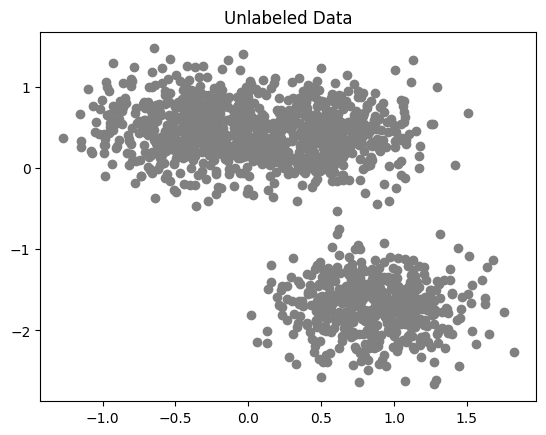

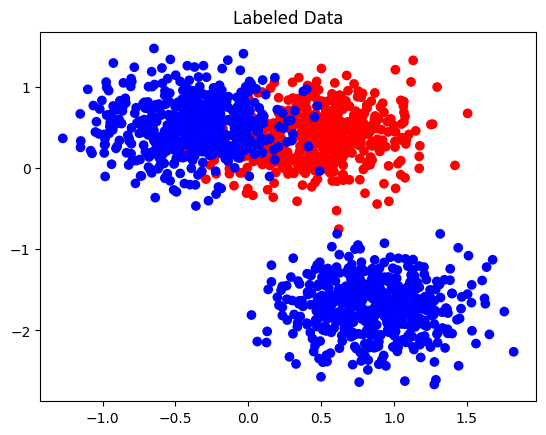

In [4]:
viz.dataset_visualization(dataset.data, dataset.labels)

In [5]:
exp_zero = EdgeAlterationExperiment(
    n_runs=3,
    num_rounds=20,
    number_neighbors=30,
    kernel="gaussian",
    alteration_strategy="zero",
    rng=np.random.default_rng(42),
)

exp_negate = EdgeAlterationExperiment(
    n_runs=3,
    num_rounds=20,
    number_neighbors=30,
    kernel="gaussian",
    alteration_strategy="negate",
    rng=np.random.default_rng(42),
)

In [6]:
result_zero = exp_zero.run(dataset)
result_negate = exp_negate.run(dataset)

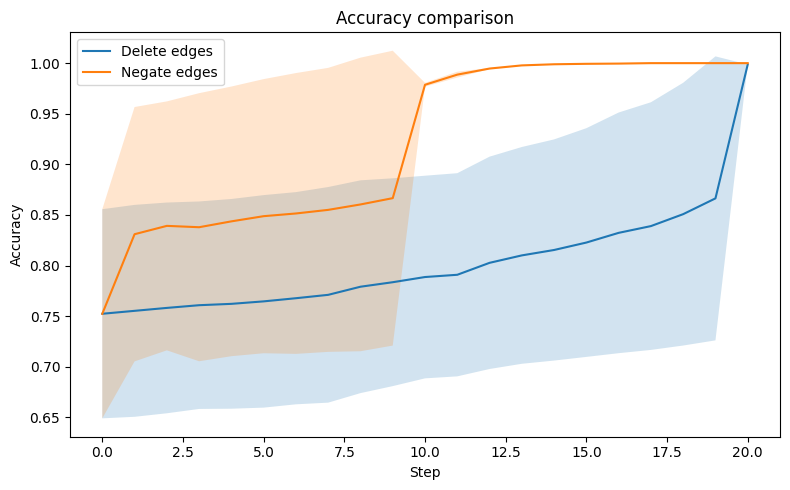

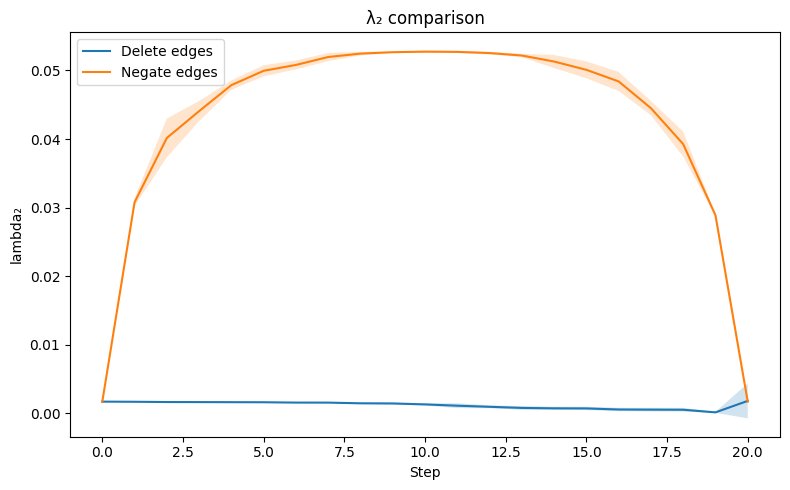

In [8]:
viz_only_edges.plot_metric_comparison(
    [result_zero, result_negate],
    "accuracy_history",
    ["Delete edges", "Negate edges"],
    title="Accuracy comparison"
)

viz_only_edges.plot_metric_comparison(
    [result_zero, result_negate],
    "lam2_history",
    ["Delete edges", "Negate edges"],
    title="λ₂ comparison"
)



In [9]:
run = result_negate.runs[0]

print(len(run.embedding_history))
print(run.embedding_history[0].shape)

21
(1500, 2)


In [10]:
anim = viz_only_edges.animate_embedding_history(run, dataset.labels)
HTML(anim.to_jshtml())

In [11]:
viz_only_edges.animate_embedding_true_vs_pred
anim = viz_only_edges.animate_embedding_true_vs_pred(run, dataset.labels)
HTML(anim.to_jshtml())

TypeError: unhashable type: 'list'